In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


# Boston Housing Price Prediction using ANN

 - CRIM  -	Crime Rate
 - ZN - Residential Zoning Land
 - INDUS - Non-Retail Industrial Area
 - CHAS - Charles River Boundary
 - NOX - Nitric Oxide Concentration
 - RM - Average Rooms per Dwelling
 - AGE - Age of Houses
 - DIS - Distance to Employment Centers
 - RAD - Radial Highway Accessibility
 - TAX - Property Tax Rate
 - PTRATIO - Pupil-Teacher Ratio
 - B - Black Population Index
 - LSTAT	Lower Status Population Percentage
 - MEDV	Median Home Value

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import r2_score

tf.random.set_seed(45)


from warnings import filterwarnings
filterwarnings('ignore')

In [5]:
df = pd.read_csv(r"C:\Users\user\Downloads\HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [8]:
df.shape

(506, 14)

In [9]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [11]:
for i in df.columns:
    print(f"{i} : {df[i].unique()}")

CRIM : [6.32000e-03 2.73100e-02 2.72900e-02 3.23700e-02 6.90500e-02 2.98500e-02
 8.82900e-02 1.44550e-01 2.11240e-01 1.70040e-01 2.24890e-01 1.17470e-01
 9.37800e-02 6.29760e-01 6.37960e-01 6.27390e-01 1.05393e+00 7.84200e-01
 8.02710e-01 7.25800e-01 1.25179e+00 8.52040e-01 1.23247e+00 9.88430e-01
 7.50260e-01 8.40540e-01 6.71910e-01 9.55770e-01 7.72990e-01 1.00245e+00
 1.13081e+00 1.35472e+00 1.38799e+00 1.15172e+00 1.61282e+00 6.41700e-02
 9.74400e-02 8.01400e-02 1.75050e-01 2.76300e-02 3.35900e-02 1.27440e-01
 1.41500e-01 1.59360e-01 1.22690e-01 1.71420e-01 1.88360e-01 2.29270e-01
 2.53870e-01 2.19770e-01 8.87300e-02 4.33700e-02 5.36000e-02         nan
 1.36000e-02 1.31100e-02 2.05500e-02 1.43200e-02 1.54450e-01 1.03280e-01
 1.49320e-01 1.71710e-01 1.10270e-01 1.26500e-01 1.95100e-02 3.58400e-02
 4.37900e-02 5.78900e-02 1.35540e-01 1.28160e-01 8.82600e-02 1.58760e-01
 9.16400e-02 1.95390e-01 7.89600e-02 9.51200e-02 1.01530e-01 8.70700e-02
 5.64600e-02 8.38700e-02 4.11300e-02 4.46200

In [14]:
df.CRIM = df.CRIM.fillna(df.CRIM.median())
df.ZN = df.ZN.fillna(df.ZN.median())
df.INDUS = df.INDUS.fillna(df.INDUS.median())
df.CHAS = df.CHAS.fillna(df.CHAS.median())
df.AGE = df.AGE.fillna(df.AGE.median())
df.LSTAT = df.LSTAT.fillna(df.LSTAT.median())

In [15]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [16]:
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [17]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.479140,10.768775,11.028893,0.067194,0.554695,6.284634,68.845850,3.795043,9.549407,408.237154,18.455534,356.674032,12.664625,22.532806
std,8.570832,23.025124,6.704679,0.250605,0.115878,0.702617,27.486962,2.105710,8.707259,168.537116,2.164946,91.294864,7.017219,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083235,0.000000,5.190000,0.000000,0.449000,5.885500,45.925000,2.100175,4.000000,279.000000,17.400000,375.377500,7.230000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,2.808720,0.000000,18.100000,0.000000,0.624000,6.623500,93.575000,5.188425,24.000000,666.000000,20.200000,396.225000,16.570000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [19]:
df[df.duplicated()]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV


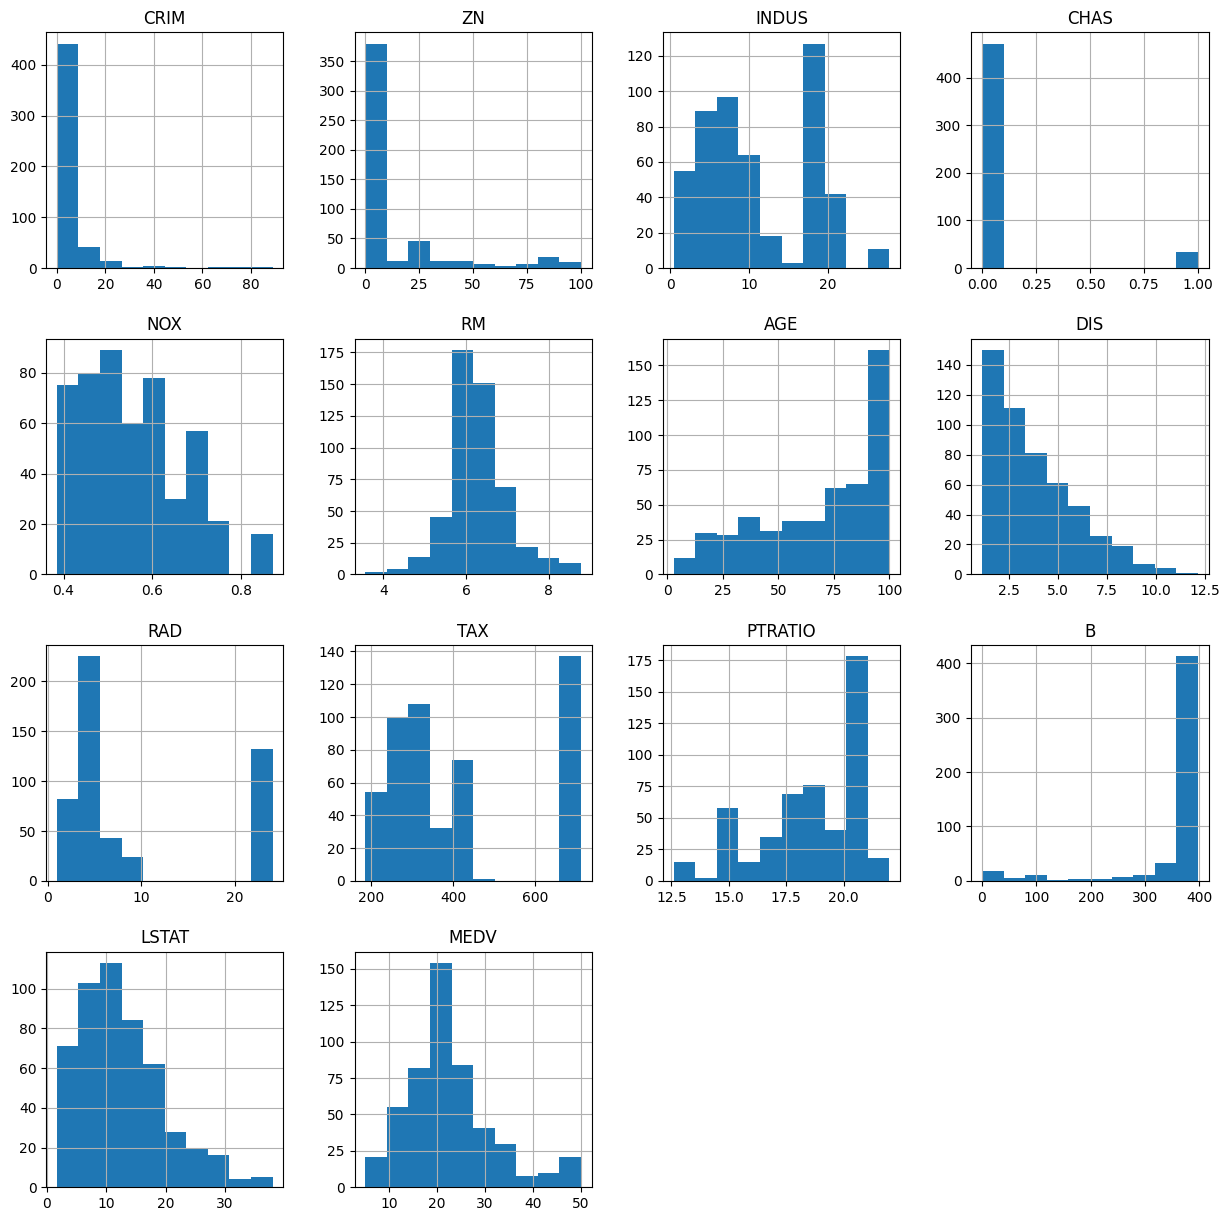

In [24]:
df.hist(figsize=(15, 15))
plt.show()

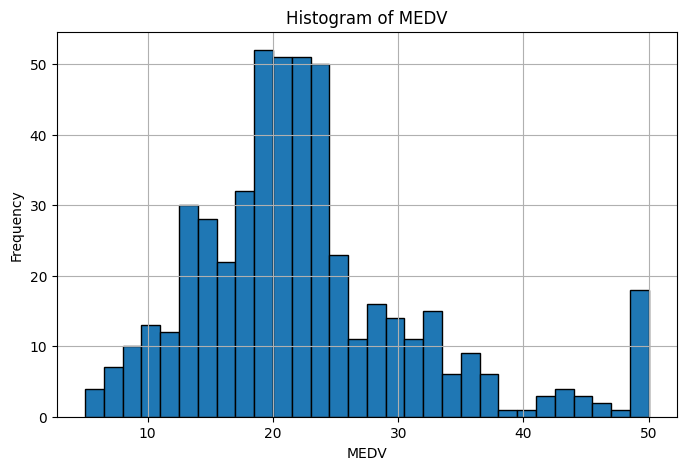

In [20]:
plt.figure(figsize=(8, 5))
df[i].hist(bins=30, edgecolor='black')
plt.title(f'Histogram of {i}')
plt.xlabel(i)
plt.ylabel('Frequency')
plt.show()

In [28]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

### Normalization

In [32]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    

### Building the ANN model

In [34]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])


In [38]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [39]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3009 (11.75 KB)
Trainable params: 3009 (11.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [40]:
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100

11/11 [==============================] - 2s 25ms/step - loss: 8.9255 - mae: 2.0507 - val_loss: 18.1411 - val_mae: 2.5664
Epoch 2/100
11/11 [==============================] - 0s 8ms/step - loss: 8.8832 - mae: 2.0845 - val_loss: 18.7554 - val_mae: 2.6440
Epoch 3/100
11/11 [==============================] - 0s 8ms/step - loss: 8.6251 - mae: 2.0207 - val_loss: 18.5438 - val_mae: 2.6365
Epoch 4/100
11/11 [==============================] - 0s 8ms/step - loss: 8.4692 - mae: 2.0106 - val_loss: 18.9457 - val_mae: 2.6270
Epoch 5/100
11/11 [==============================] - 0s 9ms/step - loss: 8.4247 - mae: 2.0146 - val_loss: 19.4076 - val_mae: 2.7525
Epoch 6/100
11/11 [==============================] - 0s 7ms/step - loss: 8.4866 - mae: 2.0038 - val_loss: 19.1773 - val_mae: 2.6931
Epoch 7/100
11/11 [==============================] - 0s 7ms/step - loss: 8.3557 - mae: 1.9881 - val_loss: 18.7799 - val_mae: 2.6325
Epoch 8/100
11/11 [==============================] - 0s 7ms/step - loss: 8

In [43]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Test MAE: {test_mae}")

4/4 [==============================] - 0s 4ms/step - loss: 13.5684 - mae: 2.7340
Test MAE: 2.734043598175049


In [44]:
y_pred = model.predict(X_test_scaled)

4/4 [==============================] - 0s 7ms/step


In [45]:
#calculating R2 score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

R2 Score: 0.8744574282904698
